# Évaluation finale — EfficientNet-B0

Charge le modèle final sauvegardé par `train_final.ipynb` et l'évalue sur le **jeu de test final** (split `test` HuggingFace, jamais vu pendant la CV ni la recherche d'hyperparamètres).

Métriques calculées : **accuracy**, **precision**, **recall**, **F1-score** (macro), **ROC-AUC** (one-vs-rest).

Sorties (dossier `results/efficientnet/evaluation/`) :

- `metrics.json` — métriques + classification report,
- `confusion_matrix.png`,
- `metrics_bar.png`,
- `predictions.png`.

/media/DATA/Projects/bellinna/Zoidberg2.0/venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


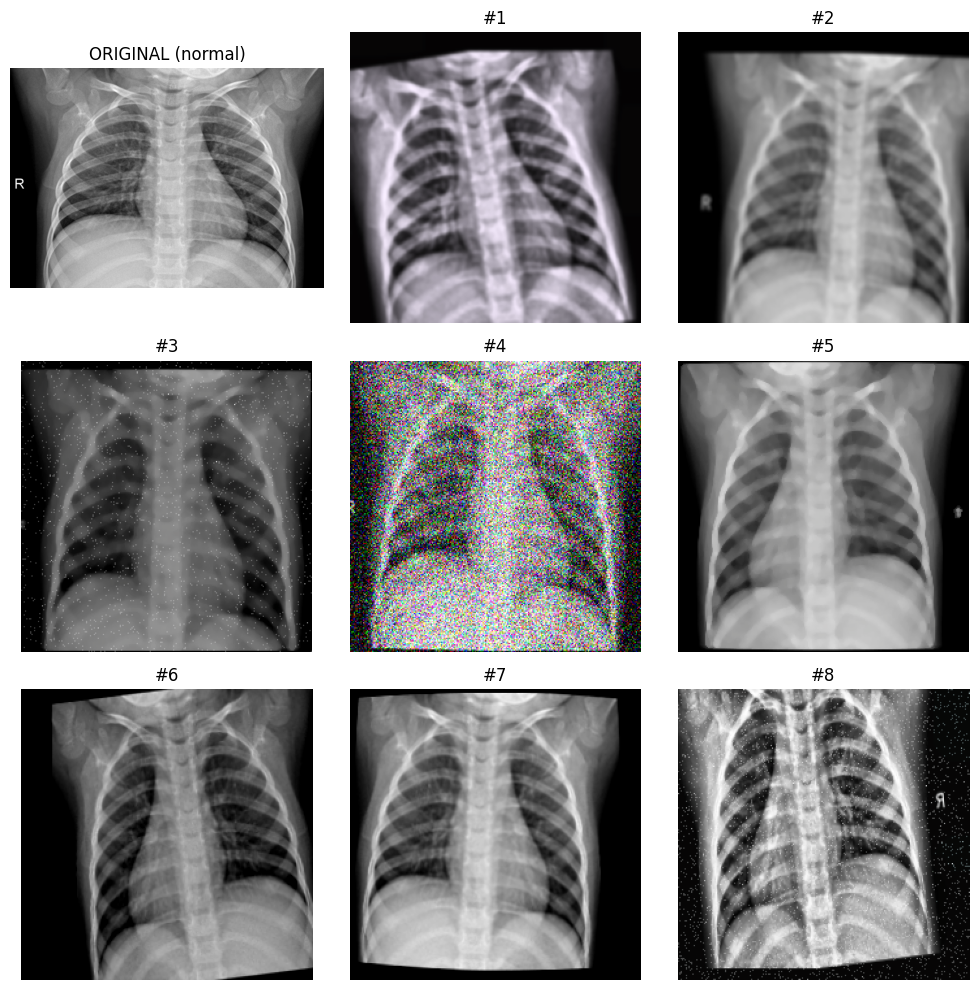

Device: cuda


In [1]:
import gc, json, sys
from datetime import datetime
from pathlib import Path

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score)

ROOT = Path.cwd().resolve()
while not (ROOT / "cross_validation.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from ipynb.fs.full.preprocessing import get_data_pipeline

FINAL_DIR = ROOT / "results" / "efficientnet" / "final_model"
EVAL_DIR = ROOT / "results" / "efficientnet" / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

## 1. Chargement du modèle final

L'architecture est reconstruite à l'identique, puis les poids `efficientnet_b0_final.pt` sont chargés.

In [2]:
with open(FINAL_DIR / "train_meta.json") as f:
    meta = json.load(f)
cfg = meta["config"]
print("Config du modèle final :")
print(json.dumps(cfg, indent=2))

NUM_CLASSES = 3
model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load(FINAL_DIR / meta["weights_file"], map_location=device))
model = model.to(device).eval()
print(f"Modèle chargé : {meta['weights_file']}")

Config du modèle final :
{
  "learning_rate": 0.0001,
  "batch_size": 32,
  "num_epochs": 8,
  "transfer_learning": true
}
Modèle chargé : efficientnet_b0_final.pt


## 2. Jeu de test final

On utilise exclusivement la vue test fournie par `preprocessing.ipynb` (resize + normalize, **pas** d'augmentation).

In [3]:
pipeline = get_data_pipeline()
test_view = pipeline["test_view"]
label_names = list(pipeline["label_names"].values())
print(f"Test set : {len(test_view)} images, classes = {label_names}")

test_loader = DataLoader(test_view, batch_size=cfg["batch_size"], shuffle=False,
                         num_workers=8, pin_memory=torch.cuda.is_available(),
                         persistent_workers=True)

Test set : 624 images, classes = ['normal', 'bacteria', 'virus']


## 3. Prédictions et métriques

Inférence sur l'ensemble du test set, puis calcul des métriques macro-averaged (équilibrage entre les 3 classes).

In [4]:
all_y, all_p, all_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)
        probs = torch.softmax(model(x), dim=1)
        preds = probs.argmax(1)
        all_y.extend(y.cpu().tolist())
        all_p.extend(preds.cpu().tolist())
        all_probs.extend(probs.cpu().numpy())

all_y = np.array(all_y); all_p = np.array(all_p); all_probs = np.array(all_probs)

metrics = {
    "accuracy": accuracy_score(all_y, all_p),
    "precision": precision_score(all_y, all_p, average="macro", zero_division=0),
    "recall": recall_score(all_y, all_p, average="macro", zero_division=0),
    "f1": f1_score(all_y, all_p, average="macro", zero_division=0),
}
try:
    metrics["roc_auc"] = roc_auc_score(all_y, all_probs, multi_class="ovr")
except ValueError:
    metrics["roc_auc"] = float("nan")

for k, v in metrics.items():
    print(f"{k:10s} {v:.4f}")

report = classification_report(all_y, all_p, target_names=label_names, output_dict=True)
print("\n" + classification_report(all_y, all_p, target_names=label_names))

accuracy   0.8413
precision  0.8436
recall     0.8445
f1         0.8301
roc_auc    0.9616

              precision    recall  f1-score   support

      normal       0.98      0.70      0.81       234
    bacteria       0.90      0.96      0.93       242
       virus       0.65      0.88      0.75       148

    accuracy                           0.84       624
   macro avg       0.84      0.84      0.83       624
weighted avg       0.87      0.84      0.84       624



## 4. Matrice de confusion

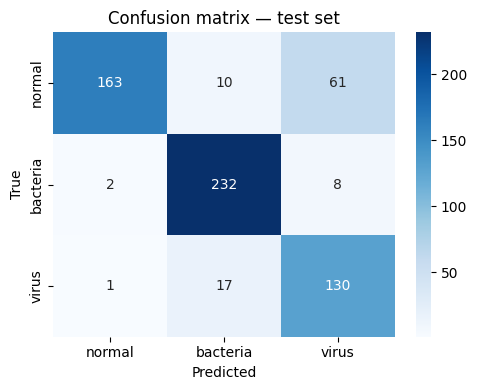

In [5]:
cm = confusion_matrix(all_y, all_p)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix — test set")
plt.tight_layout()
plt.savefig(EVAL_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## 5. Bar-chart des métriques globales

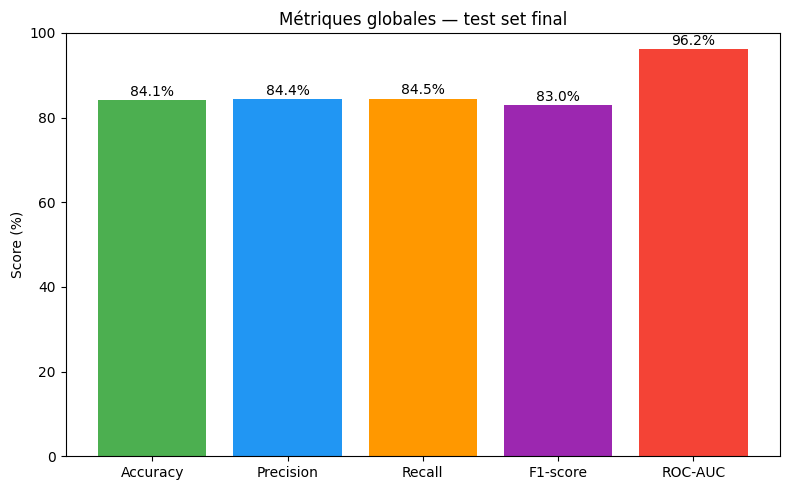

In [6]:
names = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
vals = [metrics["accuracy"], metrics["precision"], metrics["recall"],
        metrics["f1"], metrics["roc_auc"]]
pcts = [v * 100 for v in vals]
plt.figure(figsize=(8, 5))
plt.bar(names, pcts, color=["#4caf50", "#2196f3", "#ff9800", "#9c27b0", "#f44336"])
plt.ylabel("Score (%)"); plt.ylim(0, 100)
plt.title("Métriques globales — test set final")
for i, v in enumerate(pcts):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.savefig(EVAL_DIR / "metrics_bar.png", dpi=150)
plt.show()

## 6. Exemples qualitatifs

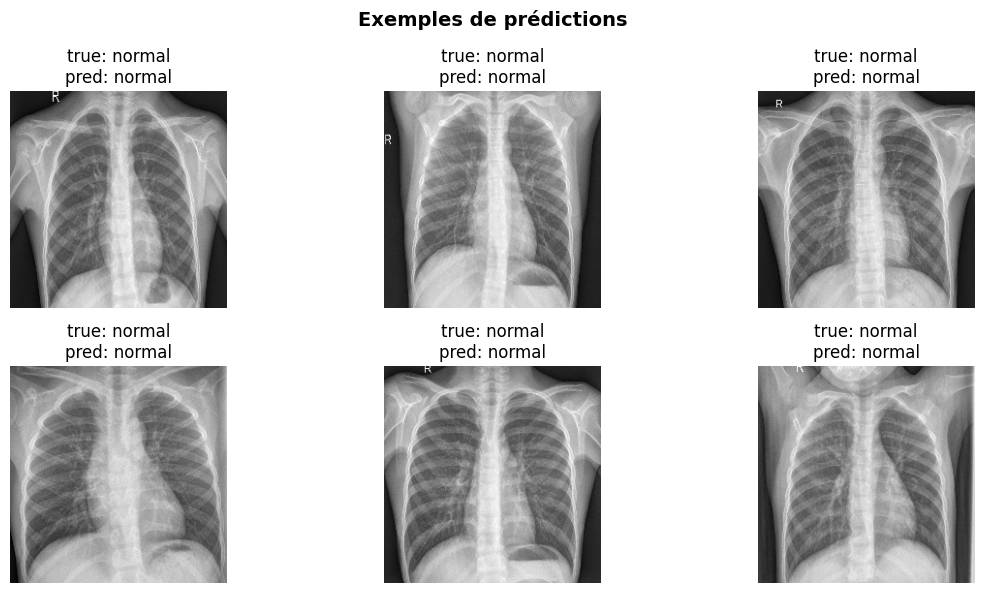

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
shown = 0
mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
with torch.no_grad():
    for batch in test_loader:
        x = batch["image"].to(device); y = batch["label"].to(device)
        preds = model(x).argmax(1)
        for i in range(x.size(0)):
            if shown >= 6:
                break
            img = x[i].cpu().numpy().transpose(1, 2, 0) * std + mean
            img = np.clip(img, 0, 1)
            axes[shown].imshow(img); axes[shown].axis("off")
            axes[shown].set_title(f"true: {label_names[y[i].item()]}\npred: {label_names[preds[i].item()]}")
            shown += 1
        if shown >= 6:
            break
plt.suptitle("Exemples de prédictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(EVAL_DIR / "predictions.png", dpi=150)
plt.show()

## 7. Sauvegarde des métriques

In [8]:
out = {
    "model": "EfficientNetB0",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "config": cfg,
    "test_size": int(len(test_view)),
    "metrics": metrics,
    "classification_report": report,
    "confusion_matrix": cm.tolist(),
}
with open(EVAL_DIR / "metrics.json", "w") as f:
    json.dump(out, f, indent=2)
print(f"Sauvegardé : {EVAL_DIR / 'metrics.json'}")

del model, test_loader
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Sauvegardé : /media/DATA/Projects/bellinna/Zoidberg2.0/results/efficientnet/evaluation/metrics.json
